<h1 style="color: #1e3a8a; background-color: #dbeafe; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Projet 12 - Exploration, fusion et préparation des données</h1>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

#____ Affichage ____#
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

print("Imports OK")

Imports OK


In [4]:
#____ Chargement des fichiers ____#

# Dataset 1
crop_yield = pd.read_csv('../inputs/crop_yield.csv')

# Dataset 2
pesticides = pd.read_csv('../inputs/Crop Yield Prediction Dataset/pesticides.csv')
rainfall   = pd.read_csv('../inputs/Crop Yield Prediction Dataset/rainfall.csv')
temp       = pd.read_csv('../inputs/Crop Yield Prediction Dataset/temp.csv')
yield_df   = pd.read_csv('../inputs/Crop Yield Prediction Dataset/yield_df.csv')
yield_raw  = pd.read_csv('../inputs/Crop Yield Prediction Dataset/yield.csv')

print("Tous les fichiers chargés avec succès")

Tous les fichiers chargés avec succès


<h1 style="color: #1e3a8a; background-color: #dbeafe; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Exploration Initiale des Données</h1>

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Data Profiling</h2>

In [5]:
# Fonction utilitaire d'exploration générique
# Appliquée à chaque dataframe, elle affiche les dimensions, types, valeurs manquantes,
# un aperçu des données, les statistiques descriptives et la cardinalité de chaque colonne.

def explore(df, name):
    print(f"\n{'='*60}")
    print(f"  FICHIER : {name}")
    print(f"{'='*60}")
    print(f"Dimensions       : {df.shape}")
    print(f"\n--- Types de colonnes ---")
    print(df.dtypes)
    print(f"\n--- Valeurs manquantes ---")
    print(df.isnull().sum())
    print(f"\n--- Aperçu (5 premières lignes) ---")
    display(df.head())
    print(f"\n--- Statistiques descriptives ---")
    display(df.describe())
    print(f"\n--- Cardinalité par colonne ---")
    print(df.nunique())

In [6]:
# Application de la fonction d'exploration sur les 6 fichiers chargés
# Explorationde  la structure, la granularité et la qualité de chaque source.

explore(crop_yield, "crop_yield.csv")
explore(pesticides, "pesticides.csv")
explore(rainfall, "rainfall.csv")
explore(temp, "temp.csv")
explore(yield_df, "yield_df.csv")
explore(yield_raw, "yield.csv")


  FICHIER : crop_yield.csv
Dimensions       : (1000000, 10)

--- Types de colonnes ---
Region                        str
Soil_Type                     str
Crop                          str
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition             str
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

--- Valeurs manquantes ---
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

--- Aperçu (5 premières lignes) ---


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251



--- Statistiques descriptives ---


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372



--- Cardinalité par colonne ---
Region                          4
Soil_Type                       6
Crop                            6
Rainfall_mm               1000000
Temperature_Celsius       1000000
Fertilizer_Used                 2
Irrigation_Used                 2
Weather_Condition               3
Days_to_Harvest                90
Yield_tons_per_hectare    1000000
dtype: int64

  FICHIER : pesticides.csv
Dimensions       : (4349, 7)

--- Types de colonnes ---
Domain         str
Area           str
Element        str
Item           str
Year         int64
Unit           str
Value      float64
dtype: object

--- Valeurs manquantes ---
Domain     0
Area       0
Element    0
Item       0
Year       0
Unit       0
Value      0
dtype: int64

--- Aperçu (5 premières lignes) ---


...


--- Cardinalité par colonne ---
Unnamed: 0                       28242
Area                               101
Item                                10
Year                                23
hg/ha_yield                      11514
average_rain_fall_mm_per_year      100
pesticides_tonnes                 1673
avg_temp                          1831
dtype: int64

  FICHIER : yield.csv
Dimensions       : (56717, 12)

--- Types de colonnes ---
Domain Code       str
Domain            str
Area Code       int64
Area              str
Element Code    int64
Element           str
Item Code       int64
Item              str
Year Code       int64
Year            int64
Unit              str
Value           int64
dtype: object

--- Valeurs manquantes ---
Domain Code     0
Domain          0
Area Code       0
Area            0
Element Code    0
Element         0
Item Code       0
Item            0
Year Code       0
Year            0
Unit            0
Value           0
dtype: int64

--- Aperçu (5 premières l

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400



--- Statistiques descriptives ---


,Area Code,Element Code,Item Code,Year Code,Year,Value
count,56717.000000,56717.0,56717.000000,56717.000000,56717.000000,56717.000000
mean,125.650422,5419.0,111.611651,1989.669570,1989.669570,62094.660084
std,75.120195,0.0,101.278435,16.133198,16.133198,67835.932856
min,1.000000,5419.0,15.000000,1961.000000,1961.000000,0.000000
25%,58.000000,5419.0,56.000000,1976.000000,1976.000000,15680.000000
50%,122.000000,5419.0,116.000000,1991.000000,1991.000000,36744.000000
75%,184.000000,5419.0,125.000000,2004.000000,2004.000000,86213.000000
max,351.000000,5419.0,489.000000,2016.000000,2016.000000,1000000.000000



--- Cardinalité par colonne ---
Domain Code         1
Domain              1
Area Code         212
Area              212
Element Code        1
Element             1
Item Code          10
Item               10
Year Code          56
Year               56
Unit                1
Value           36815
dtype: int64


### <u>Conclusions de l'exploration des données</u>

### crop_yield.csv
- Dataset synthétique de 1 000 000 lignes et **10 colonnes**.
- Aucune valeur manquante.
- Pas de colonne commune avec les autres datasets — <mark>incompatible avec une jointure directe</mark> sur les fichiers FAO (Foond & agriculture organisation).
- Variables disponibles : **Region (4 valeurs génériques), Soil_Type, Crop (6 cultures), Rainfall_mm,
  Temperature_Celsius, Fertilizer_Used, Irrigation_Used, Weather_Condition, Days_to_Harvest, Yield_tons_per_hectare**.
- Présence de <mark>valeurs négatives sur la variable cible (min = -1.15 t/ha) — **à traiter**</mark>.
- Ce dataset sera utilisé principalement pour l'ACP et l'analyse des variables agronomiques.

### pesticides.csv
- 4 349 lignes, **7 colonnes**.
- aucune valeur manquante.
- <mark>Granularité : pays (Area) + année (Year), une seule valeur par ligne (usage total de pesticides en tonnes)</mark>.
- Couverture : 168 pays, années 1990-2016.
- <mark>Colonnes `Domain`, `Element`, `Item`, `Unit` sont constantes — **à supprimer lors du nettoyage**</mark>.

### rainfall.csv
- 6 727 lignes, **3 colonnes**.
- <mark>774 **valeurs manquantes** sur `average_rain_fall_mm_per_year` (11.5%)</mark>.
- <mark>La colonne `average_rain_fall_mm_per_year` est de type string — **conversion numérique nécessaire**.<mark>
- Couverture : 217 pays, années 1985-2017.
- <mark>Colonne `Area` contient un espace en tête — **à corriger**.</mark>

### temp.csv
- 71 311 lignes, **3 colonnes**.
- <mark>2 547 **valeurs manquantes** sur `avg_temp` (3.6%)</mark>.
- <mark>Historique 1743-2013 — **filtration sur la période pertinente** 1990-2013</mark>.
- <mark>Colonnes nommées `year` et `country` **(minuscules) — à harmoniser** avec les autres fichiers</mark>.
- Couverture : 137 pays.

### yield_df.csv
- 28 242 lignes, **8 colonnes**.
- aucune valeur manquante.
- <mark>**Ce fichier est déjà le résultat d'une fusion des fichiers FAO</mark> (Area + Item + Year + hg/ha_yield +
  rainfall + pesticides + avg_temp).
- Couverture : 101 pays, 10 cultures, années 1990-2013.
- <mark>Colonne `Unnamed: 0` : **index résiduel à supprimer**<mark>.
- Servira de référence de cohérence pour valider notre propre reconstruction.

### yield.csv
- 56 717 lignes, **12 colonnes**;
- aucune valeur manquante.
- Source FAO brute des rendements par culture, pays et année.
- Couverture plus large : 212 pays, 10 cultures, années 1961-2016.
- <mark>Colonnes `Domain Code`, `Domain`, `Element Code`, `Element`, `Year Code`, `Unit` **sont constantes — à supprimer**</mark>.
- Variable cible : `Value` en hg/ha.

### Conclusion :
Les deux datasets sources sont structurellement incompatibles pour une jointure directe.
<mark>`crop_yield.csv` ne contient ni pays ni année, ce qui exclut toute jointure avec les fichiers FAO</mark>.
**<u>La stratégie retenue est la suivante :</u>**
- Utiliser `yield_df.csv` dataset final après avoir vérifié qu'il contient toutes les informations des fichiers dont il découle (`yield.csv`, `pesticides.csv`, `rainfall.csv` et `temp.csv` sur les clés `Area` + `Year`).
- Traiter `crop_yield.csv` séparément pour l'ACP et l'analyse des variables agronomiques.

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">yield_df.csv</h2>

In [7]:
# Vérification structurale que yield_df.csv contient bien toutes les informations
# issues de ses fichiers sources (yield.csv, pesticides.csv, rainfall.csv, temp.csv)
# sur les clés Area + Year avant de le valider comme dataset final.

print("=" * 60)
print("1. COUVERTURE TEMPORELLE")
print("=" * 60)
print(f"yield_df  — années : {sorted(yield_df['Year'].unique())}")
print(f"yield     — années : {yield_raw['Year'].min()} → {yield_raw['Year'].max()}")
print(f"pesticides— années : {pesticides['Year'].min()} → {pesticides['Year'].max()}")
print(f"rainfall  — années : {rainfall['Year'].min()} → {rainfall['Year'].max()}")
print(f"temp      — années : {temp['year'].min()} → {temp['year'].max()}")

print("\n" + "=" * 60)
print("2. COUVERTURE GÉOGRAPHIQUE (nombre de pays)")
print("=" * 60)
print(f"yield_df   : {yield_df['Area'].nunique()} pays")
print(f"yield      : {yield_raw['Area'].nunique()} pays")
print(f"pesticides : {pesticides['Area'].nunique()} pays")
print(f"rainfall   : {rainfall[' Area'].str.strip().nunique()} pays")
print(f"temp       : {temp['country'].nunique()} pays")

print("\n" + "=" * 60)
print("3. CULTURES PRÉSENTES")
print("=" * 60)
print(f"yield_df : {sorted(yield_df['Item'].unique())}")
print(f"yield    : {sorted(yield_raw['Item'].unique())}")

print("\n" + "=" * 60)
print("4. COLONNES DE yield_df vs fichiers sources")
print("=" * 60)
print(f"yield_df colonnes     : {list(yield_df.columns)}")
print(f"Colonne rainfall src  : 'average_rain_fall_mm_per_year' → présente : {'average_rain_fall_mm_per_year' in yield_df.columns}")
print(f"Colonne pesticides src: 'pesticides_tonnes'             → présente : {'pesticides_tonnes' in yield_df.columns}")
print(f"Colonne temp src      : 'avg_temp'                      → présente : {'avg_temp' in yield_df.columns}")
print(f"Colonne rendement src : 'hg/ha_yield'                   → présente : {'hg/ha_yield' in yield_df.columns}")

print("\n" + "=" * 60)
print("5. PAYS PRÉSENTS DANS yield_df MAIS ABSENTS DES SOURCES")
print("=" * 60)
pays_yield_df  = set(yield_df['Area'].unique())
pays_yield_raw = set(yield_raw['Area'].unique())
pays_pest      = set(pesticides['Area'].unique())
pays_rain      = set(rainfall[' Area'].str.strip().unique())
pays_temp      = set(temp['country'].unique())

print(f"Pays dans yield_df absents de yield.csv     : {pays_yield_df - pays_yield_raw}")
print(f"Pays dans yield_df absents de pesticides.csv: {pays_yield_df - pays_pest}")
print(f"Pays dans yield_df absents de rainfall.csv  : {pays_yield_df - pays_rain}")
print(f"Pays dans yield_df absents de temp.csv      : {pays_yield_df - pays_temp}")

1. COUVERTURE TEMPORELLE
yield_df  — années : [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)]
yield     — années : 1961 → 2016
pesticides— années : 1990 → 2016
rainfall  — années : 1985 → 2017
temp      — années : 1743 → 2013

2. COUVERTURE GÉOGRAPHIQUE (nombre de pays)
yield_df   : 101 pays
yield      : 212 pays
pesticides : 168 pays
rainfall   : 217 pays
temp       : 137 pays

3. CULTURES PRÉSENTES
yield_df : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']
yield    : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', '

### <u>Vérification structurale de yield_df.csv — Conclusions</u>

<mark>`yield_df.csv` est **validé comme dataset final** pour les étapes suivantes</mark>.

### Résultats de la vérification

- **Cultures** : les 10 cultures sont identiques à celles de `yield.csv`.
- **Colonnes sources** : les 4 variables issues des fichiers sources sont toutes présentes
  (`average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp`, `hg/ha_yield`).
- **Cohérence géographique** : aucun pays présent dans `yield_df.csv` n'est absent
  de ses fichiers sources.
- **Couverture réduite** : 101 pays et années 1990-2013 — correspond à l'intersection
  des fichiers sources sur la période commune, attendu et justifié.
- **Année 2003 manquante** : l'année 2003 est **absente de `yield_df.csv`**. Les fichiers
  sources contiennent bien les données 2003 mais la reconstruction manuelle d'une année
  isolée introduirait un risque d'incohérence. Cette absence est documentée et sans
  impact significatif sur la modélisation (23 années disponibles sur 24).

### Dataset final retenu

| Caractéristique | Valeur |
|---|---|
| Fichier | `yield_df.csv` |
| Dimensions | 28 242 lignes × 8 colonnes |
| Valeurs manquantes | Aucune |
| Pays | 101 |
| Cultures | 10 |
| Période | 1990-2013 (hors 2003) |
| Variable cible | `hg/ha_yield` (rendement en hectogrammes par hectare) |
| Colonne à supprimer | `Unnamed: 0` (index résiduel) |

In [8]:
# Détection et quantification des doublons dans yield_df.csv

print("=" * 60)
print("DOUBLONS")
print("=" * 60)

total_doublons = yield_df.duplicated().sum()
print(f"Nombre de lignes dupliquées (toutes colonnes) : {total_doublons}")
print(f"Soit {round(total_doublons / len(yield_df) * 100, 2)}% du dataset")

print("\n--- Doublons sur les clés métier (Area + Item + Year) ---")
doublons_cles = yield_df.duplicated(subset=['Area', 'Item', 'Year']).sum()
print(f"Nombre de doublons sur Area + Item + Year : {doublons_cles}")
print(f"Soit {round(doublons_cles / len(yield_df) * 100, 2)}% du dataset")

print("\n--- Pays les plus concernés par les doublons ---")
doublons_details = yield_df[yield_df.duplicated(subset=['Area', 'Item', 'Year'], keep=False)]
print(f"Nombre de lignes impliquées : {len(doublons_details)}")
print(f"\nTop 10 des pays concernés :")
print(doublons_details.groupby('Area').size().sort_values(ascending=False).head(10))

DOUBLONS
Nombre de lignes dupliquées (toutes colonnes) : 0
Soit 0.0% du dataset

--- Doublons sur les clés métier (Area + Item + Year) ---
Nombre de doublons sur Area + Item + Year : 15112
Soit 53.51% du dataset

--- Pays les plus concernés par les doublons ---
Nombre de lignes impliquées : 18949

Top 10 des pays concernés :
Area
India           4048
Brazil          2277
Mexico          1472
Pakistan        1449
Australia        966
Japan            966
Indonesia        828
South Africa     644
Turkey           625
Ecuador          621
dtype: int64


In [9]:
# Correction des doublons sur Area + Item + Year
# Cause : temp.csv contient plusieurs valeurs de température par pays/année
# (plusieurs régions ou stations météo)
# Solution : agréger avg_temp par moyenne, les autres colonnes étant identiques

print("=" * 60)
print("CORRECTION DES DOUBLONS")
print("=" * 60)

print(f"Dimensions avant correction : {yield_df.shape}")

yield_df_clean = yield_df.groupby(
    ['Area', 'Item', 'Year'],
    as_index=False
).agg(
    hg_ha_yield=('hg/ha_yield', 'first'),
    average_rain_fall_mm_per_year=('average_rain_fall_mm_per_year', 'first'),
    pesticides_tonnes=('pesticides_tonnes', 'first'),
    avg_temp=('avg_temp', 'mean')
)

print(f"Dimensions après correction  : {yield_df_clean.shape}")
print(f"Doublons résiduels sur Area + Item + Year : {yield_df_clean.duplicated(subset=['Area', 'Item', 'Year']).sum()}")
print(f"\nApercu :")
display(yield_df_clean.head())

CORRECTION DES DOUBLONS
Dimensions avant correction : (28242, 8)
Dimensions après correction  : (13130, 7)
Doublons résiduels sur Area + Item + Year : 0

Apercu :


,Area,Item,Year,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Maize,1991,29068,1485.0,121.0,15.36
2,Albania,Maize,1992,24876,1485.0,121.0,16.06
3,Albania,Maize,1993,24185,1485.0,121.0,16.05
4,Albania,Maize,1994,25848,1485.0,201.0,16.96


In [10]:
# Vérification des valeurs manquantes et des types après correction

print("=" * 60)
print("3. VALEURS MANQUANTES")
print("=" * 60)
print(yield_df_clean.isnull().sum())
print(f"\nTaux de NA global : {round(yield_df_clean.isnull().sum().sum() / yield_df_clean.size * 100, 2)}%")

print("\n" + "=" * 60)
print("4. TYPES DE COLONNES")
print("=" * 60)
print(yield_df_clean.dtypes)

print("\n" + "=" * 60)
print("5. STATISTIQUES DESCRIPTIVES")
print("=" * 60)
display(yield_df_clean.describe())

3. VALEURS MANQUANTES
Area                             0
Item                             0
Year                             0
hg_ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Taux de NA global : 0.0%

4. TYPES DE COLONNES
Area                                 str
Item                                 str
Year                               int64
hg_ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

5. STATISTIQUES DESCRIPTIVES


,Year,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,13130.000000,13130.000000,13130.000000,13130.000000,13130.000000
mean,2001.622772,70968.615461,1157.238766,14838.697886,19.836531
std,7.033139,79124.283809,743.622488,33652.454670,6.658083
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,18000.000000,608.000000,264.530000,15.670000
50%,2001.000000,39543.500000,1083.000000,2172.200000,20.620000
75%,2008.000000,97152.250000,1651.000000,13335.220000,25.780000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.420000


6. DETECTION DES OUTLIERS — REGLE IQR

  hg_ha_yield
  Q1=18000.00 | Q3=97152.25 | IQR=79152.25
  Bornes : [-100728.38 ; 215880.62]
  Nombre d'outliers : 814 (6.2%)
  Min outlier : 215966.00 | Max outlier : 501412.00

  average_rain_fall_mm_per_year
  Q1=608.00 | Q3=1651.00 | IQR=1043.00
  Bornes : [-956.50 ; 3215.50]
  Nombre d'outliers : 207 (1.58%)
  Min outlier : 3240.00 | Max outlier : 3240.00

  pesticides_tonnes
  Q1=264.53 | Q3=13335.22 | IQR=13070.69
  Bornes : [-19341.50 ; 32941.25]
  Nombre d'outliers : 1936 (14.74%)
  Min outlier : 33031.28 | Max outlier : 367778.00

  avg_temp
  Q1=15.67 | Q3=25.78 | IQR=10.11
  Bornes : [0.50 ; 40.95]
  Nombre d'outliers : 0 (0.0%)
  Aucun outlier

--- Visualisation ---


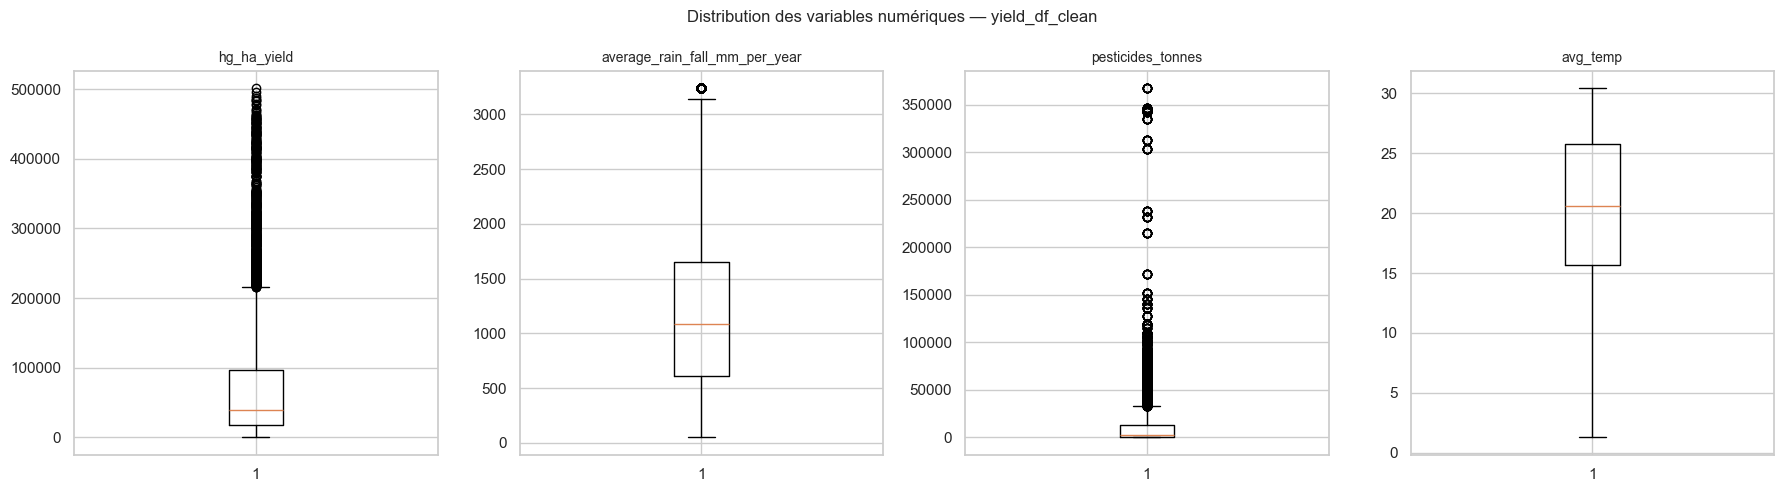

In [11]:
# Détection des valeurs aberrantes via la règle IQR sur les variables numériques

print("=" * 60)
print("6. DETECTION DES OUTLIERS — REGLE IQR")
print("=" * 60)

colonnes_num = ['hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

for col in colonnes_num:
    Q1  = yield_df_clean[col].quantile(0.25)
    Q3  = yield_df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    outliers = yield_df_clean[(yield_df_clean[col] < borne_inf) | (yield_df_clean[col] > borne_sup)]

    print(f"\n  {col}")
    print(f"  Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}")
    print(f"  Bornes : [{borne_inf:.2f} ; {borne_sup:.2f}]")
    print(f"  Nombre d'outliers : {len(outliers)} ({round(len(outliers)/len(yield_df_clean)*100, 2)}%)")
    print(f"  Min outlier : {outliers[col].min():.2f} | Max outlier : {outliers[col].max():.2f}" if len(outliers) > 0 else "  Aucun outlier")

print("\n--- Visualisation ---")
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(colonnes_num):
    axes[i].boxplot(yield_df_clean[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
plt.suptitle("Distribution des variables numériques — yield_df_clean", fontsize=12)
plt.tight_layout()
plt.show()

**<u>Conclusion concernant les outliers :</u>**
- Aucun outlier n'a été supprimé.
- Toutes les valeurs aberrantes détectées par l'IQR (Interquartile Range) sont explicables par des réalités agronomiques ou géographiques. Les supprimer biaiserait le modèle en écartant précisément les cas extrêmes qui possèdent une forte valeur prédictive.

In [12]:
# Export du dataset final nettoyé

print("=" * 60)
print("8. EXPORT DU DATASET FINAL")
print("=" * 60)

yield_df_clean.to_csv('../outputs/dataset_final.csv', index=False)

print(f"Fichier exporté : outputs/dataset_final.csv")
print(f"\nRésumé final :")
print(f"  Dimensions      : {yield_df_clean.shape}")
print(f"  Colonnes        : {list(yield_df_clean.columns)}")
print(f"  Pays            : {yield_df_clean['Area'].nunique()}")
print(f"  Cultures        : {yield_df_clean['Item'].nunique()}")
print(f"  Période         : {yield_df_clean['Year'].min()} → {yield_df_clean['Year'].max()}")
print(f"  Valeurs manquantes : {yield_df_clean.isnull().sum().sum()}")

8. EXPORT DU DATASET FINAL
Fichier exporté : outputs/dataset_final.csv

Résumé final :
  Dimensions      : (13130, 7)
  Colonnes        : ['Area', 'Item', 'Year', 'hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
  Pays            : 101
  Cultures        : 10
  Période         : 1990 → 2013
  Valeurs manquantes : 0


In [13]:
# Vérification de la cohérence des valeurs entre dataset_final.csv et ses fichiers sources
# On prend 3 exemples (pays + année) et on compare les valeurs côte à côte
# Note : avg_temp est maintenant une moyenne agrégée — on compare donc avec la moyenne de temp.csv

exemples = [
    ('Albania', 1990),
    ('France',  2000),
    ('India',   2010)
]

# Préparation des fichiers sources
pesticides_clean = pesticides[['Area', 'Year', 'Value']].rename(columns={'Value': 'pesticides_src'})

rainfall_clean = rainfall.copy()
rainfall_clean[' Area'] = rainfall_clean[' Area'].str.strip()
rainfall_clean = rainfall_clean.rename(columns={' Area': 'Area', 'average_rain_fall_mm_per_year': 'rainfall_src'})
rainfall_clean['rainfall_src'] = pd.to_numeric(rainfall_clean['rainfall_src'], errors='coerce')

temp_clean = temp.rename(columns={'country': 'Area', 'year': 'Year'})[['Area', 'Year', 'avg_temp']]
# Agrégation par moyenne pour être cohérent avec ce qu'on a fait sur yield_df_clean
temp_agg = temp_clean.groupby(['Area', 'Year'], as_index=False)['avg_temp'].mean()
temp_agg = temp_agg.rename(columns={'avg_temp': 'temp_src'})

yield_raw_clean = yield_raw[['Area', 'Item', 'Year', 'Value']].rename(columns={'Value': 'yield_src'})

print(f"{'='*80}")
print(f"{'VERIFICATION DES VALEURS — dataset_final.csv vs fichiers sources':^80}")
print(f"{'='*80}")

for pays, annee in exemples:
    print(f"\n--- {pays} | {annee} ---")

    ref = yield_df_clean[(yield_df_clean['Area'] == pays) & (yield_df_clean['Year'] == annee)]

    if ref.empty:
        print(f"  [MANQUANT] Aucune ligne trouvée dans dataset_final pour {pays} / {annee}")
        continue

    pest_val = pesticides_clean[(pesticides_clean['Area'] == pays) & (pesticides_clean['Year'] == annee)]['pesticides_src'].values
    rain_val = rainfall_clean[(rainfall_clean['Area'] == pays) & (rainfall_clean['Year'] == annee)]['rainfall_src'].values
    temp_val = temp_agg[(temp_agg['Area'] == pays) & (temp_agg['Year'] == annee)]['temp_src'].values

    print(f"\n  Valeurs dans dataset_final :")
    print(ref[['Item', 'hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']].to_string(index=False))

    print(f"\n  Valeurs dans les fichiers sources :")
    print(f"  pesticides.csv → {pest_val[0] if len(pest_val) > 0 else 'NON TROUVE'}")
    print(f"  rainfall.csv   → {rain_val[0] if len(rain_val) > 0 else 'NON TROUVE'}")
    print(f"  temp.csv       → {round(temp_val[0], 2) if len(temp_val) > 0 else 'NON TROUVE'} (moyenne agregee)")

    print(f"\n  Correspondance :")
    if len(pest_val) > 0:
        match_pest = all(ref['pesticides_tonnes'] == pest_val[0])
        print(f"  pesticides_tonnes             == pesticides.csv Value : {'OK' if match_pest else 'ERREUR'}")
    if len(rain_val) > 0:
        match_rain = all(ref['average_rain_fall_mm_per_year'] == rain_val[0])
        print(f"  average_rain_fall_mm_per_year == rainfall.csv Value   : {'OK' if match_rain else 'ERREUR'}")
    if len(temp_val) > 0:
        match_temp = all(round(ref['avg_temp'], 2) == round(temp_val[0], 2))
        print(f"  avg_temp (moyenne agregee)    == temp.csv avg_temp    : {'OK' if match_temp else 'ERREUR'}")

    for _, row in ref.drop_duplicates(subset=['Item']).iterrows():
        yield_src_val = yield_raw_clean[
            (yield_raw_clean['Area'] == pays) &
            (yield_raw_clean['Year'] == annee) &
            (yield_raw_clean['Item'] == row['Item'])
        ]['yield_src'].values
        if len(yield_src_val) > 0:
            match_yield = row['hg_ha_yield'] == yield_src_val[0]
            print(f"  hg_ha_yield ({row['Item']:<25}) == yield.csv Value : {'OK' if match_yield else 'ERREUR'}")

        VERIFICATION DES VALEURS — dataset_final.csv vs fichiers sources        

--- Albania | 1990 ---

  Valeurs dans dataset_final :
       Item  hg_ha_yield  average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp
      Maize        36613                         1485.0              121.0     16.37
   Potatoes        66667                         1485.0              121.0     16.37
Rice, paddy        23333                         1485.0              121.0     16.37
    Sorghum        12500                         1485.0              121.0     16.37
   Soybeans         7000                         1485.0              121.0     16.37
      Wheat        30197                         1485.0              121.0     16.37

  Valeurs dans les fichiers sources :
  pesticides.csv → 121.0
  rainfall.csv   → 1485.0
  temp.csv       → 16.37 (moyenne agregee)

  Correspondance :
  pesticides_tonnes             == pesticides.csv Value : OK
  average_rain_fall_mm_per_year == rainfall.csv Value 

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">crop_yield.csv</h2>

1. DOUBLONS
Nombre de lignes dupliquées (toutes colonnes) : 0
Soit 0.0% du dataset

2. VALEURS MANQUANTES
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

Taux de NA global : 0.0%

3. TYPES DE COLONNES
Region                        str
Soil_Type                     str
Crop                          str
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition             str
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

4. STATISTIQUES DESCRIPTIVES


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372



5. DETECTION DES OUTLIERS — REGLE IQR

  Rainfall_mm
  Q1=324.89 | Q3=774.74 | IQR=449.85
  Bornes : [-349.88 ; 1449.51]
  Nombre d'outliers : 0 (0.0%)
  Aucun outlier

  Temperature_Celsius
  Q1=21.25 | Q3=33.75 | IQR=12.50
  Bornes : [2.51 ; 52.50]
  Nombre d'outliers : 0 (0.0%)
  Aucun outlier

  Days_to_Harvest
  Q1=82.00 | Q3=127.00 | IQR=45.00
  Bornes : [14.50 ; 194.50]
  Nombre d'outliers : 0 (0.0%)
  Aucun outlier

  Yield_tons_per_hectare
  Q1=3.42 | Q3=5.88 | IQR=2.46
  Bornes : [-0.27 ; 9.57]
  Nombre d'outliers : 84 (0.01%)
  Min outlier : -1.15 | Max outlier : 9.96

6. VALEURS NEGATIVES SUR LA VARIABLE CIBLE
Nombre de valeurs négatives : 231 (0.02%)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
756,East,Peaty,Cotton,101.019421,33.804131,False,False,Rainy,117,-0.007103
7799,South,Chalky,Rice,108.804894,18.004082,False,False,Sunny,86,-0.061283
8421,East,Chalky,Soybean,168.120735,38.473430,False,False,Cloudy,111,-0.119911
9553,North,Silt,Wheat,156.607973,16.610257,False,False,Sunny,129,-0.193093
15435,South,Chalky,Maize,177.481344,27.719742,False,False,Sunny,94,-0.009811



--- Visualisation ---


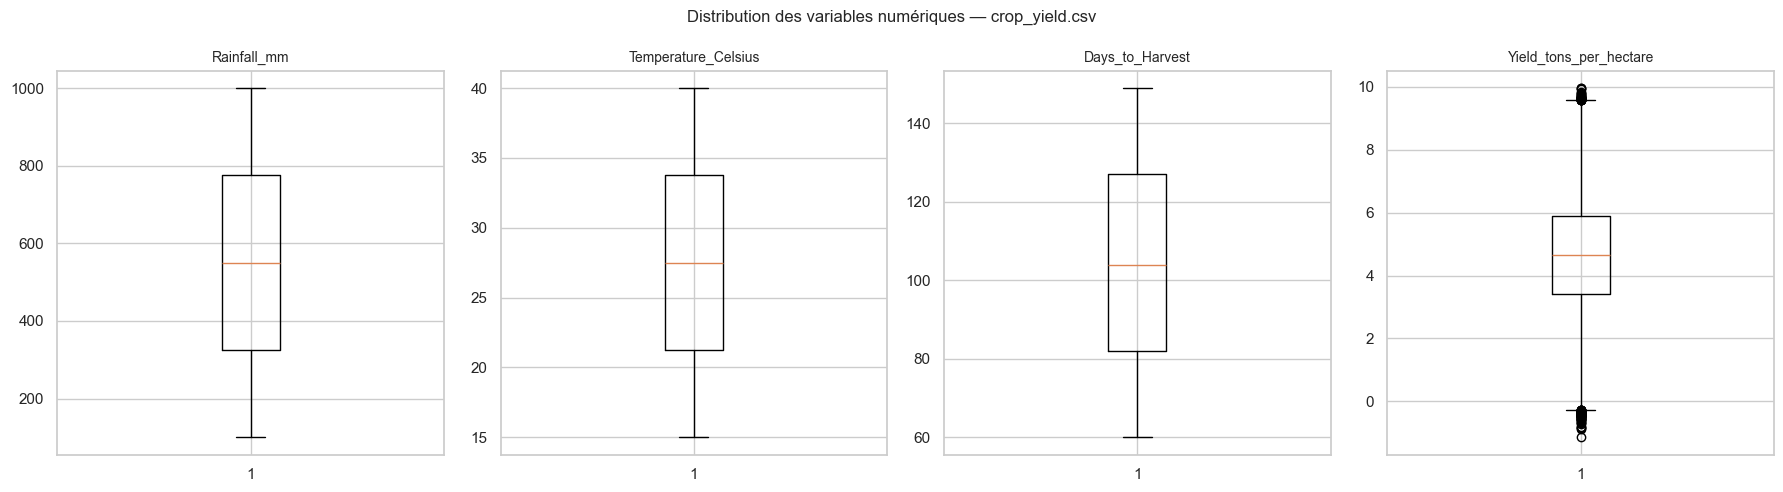

In [14]:
# Exploration et nettoyage de crop_yield.csv

print("=" * 60)
print("1. DOUBLONS")
print("=" * 60)
total_doublons = crop_yield.duplicated().sum()
print(f"Nombre de lignes dupliquées (toutes colonnes) : {total_doublons}")
print(f"Soit {round(total_doublons / len(crop_yield) * 100, 2)}% du dataset")

print("\n" + "=" * 60)
print("2. VALEURS MANQUANTES")
print("=" * 60)
print(crop_yield.isnull().sum())
print(f"\nTaux de NA global : {round(crop_yield.isnull().sum().sum() / crop_yield.size * 100, 2)}%")

print("\n" + "=" * 60)
print("3. TYPES DE COLONNES")
print("=" * 60)
print(crop_yield.dtypes)

print("\n" + "=" * 60)
print("4. STATISTIQUES DESCRIPTIVES")
print("=" * 60)
display(crop_yield.describe())

print("\n" + "=" * 60)
print("5. DETECTION DES OUTLIERS — REGLE IQR")
print("=" * 60)
colonnes_num = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Yield_tons_per_hectare']

for col in colonnes_num:
    Q1  = crop_yield[col].quantile(0.25)
    Q3  = crop_yield[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    outliers  = crop_yield[(crop_yield[col] < borne_inf) | (crop_yield[col] > borne_sup)]
    print(f"\n  {col}")
    print(f"  Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}")
    print(f"  Bornes : [{borne_inf:.2f} ; {borne_sup:.2f}]")
    print(f"  Nombre d'outliers : {len(outliers)} ({round(len(outliers)/len(crop_yield)*100, 2)}%)")
    if len(outliers) > 0:
        print(f"  Min outlier : {outliers[col].min():.2f} | Max outlier : {outliers[col].max():.2f}")
    else:
        print(f"  Aucun outlier")

print("\n" + "=" * 60)
print("6. VALEURS NEGATIVES SUR LA VARIABLE CIBLE")
print("=" * 60)
valeurs_neg = crop_yield[crop_yield['Yield_tons_per_hectare'] < 0]
print(f"Nombre de valeurs négatives : {len(valeurs_neg)} ({round(len(valeurs_neg)/len(crop_yield)*100, 2)}%)")
display(valeurs_neg.head())

print("\n--- Visualisation ---")
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(colonnes_num):
    axes[i].boxplot(crop_yield[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=10)
plt.suptitle("Distribution des variables numériques — crop_yield.csv", fontsize=12)
plt.tight_layout()
plt.show()

Conclusion Outliers :
- Uniquement sur **Yield_tons_per_hectare** : 84 outliers IQR (0.01%) mais surtout <mark>**231 valeurs négatives (0.02%)**</u>
- Les autres variables (**Rainfall**, **Temperature**, **Days_to_Harvest**) sont bien distribuées.
- Un rendement **négatif** est physiquement impossible. <mark>**Ces 231 observations doivent être supprimées</mark>**.

In [15]:
# Suppression des valeurs négatives sur Yield_tons_per_hectare

print("=" * 60)
print("7. SUPPRESSION DES VALEURS NEGATIVES")
print("=" * 60)

print(f"Dimensions avant : {crop_yield.shape}")
crop_yield_clean = crop_yield[crop_yield['Yield_tons_per_hectare'] >= 0].copy()
print(f"Dimensions après : {crop_yield_clean.shape}")
print(f"Lignes supprimées : {len(crop_yield) - len(crop_yield_clean)}")
print(f"Valeurs négatives résiduelles : {(crop_yield_clean['Yield_tons_per_hectare'] < 0).sum()}")

7. SUPPRESSION DES VALEURS NEGATIVES
Dimensions avant : (1000000, 10)
Dimensions après : (999769, 10)
Lignes supprimées : 231
Valeurs négatives résiduelles : 0


In [16]:
# Export de crop_yield_clean

print("=" * 60)
print("8. EXPORT DE CROP_YIELD_CLEAN")
print("=" * 60)

crop_yield_clean.to_csv('../outputs/crop_yield_clean.csv', index=False)

print(f"Fichier exporté : outputs/crop_yield_clean.csv")
print(f"\nRésumé final :")
print(f"  Dimensions      : {crop_yield_clean.shape}")
print(f"  Colonnes        : {list(crop_yield_clean.columns)}")
print(f"  Cultures        : {crop_yield_clean['Crop'].nunique()} — {sorted(crop_yield_clean['Crop'].unique())}")
print(f"  Régions         : {crop_yield_clean['Region'].nunique()} — {sorted(crop_yield_clean['Region'].unique())}")
print(f"  Valeurs manquantes : {crop_yield_clean.isnull().sum().sum()}")
print(f"  Valeurs négatives  : {(crop_yield_clean['Yield_tons_per_hectare'] < 0).sum()}")

8. EXPORT DE CROP_YIELD_CLEAN
Fichier exporté : outputs/crop_yield_clean.csv

Résumé final :
  Dimensions      : (999769, 10)
  Colonnes        : ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']
  Cultures        : 6 — ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']
  Régions         : 4 — ['East', 'North', 'South', 'West']
  Valeurs manquantes : 0
  Valeurs négatives  : 0


<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Conclusion générale — Exploration et préparation des données</h2>

### Rappel de l'objectif
Identifier, explorer, nettoyer et sélectionner les données nécessaires à la
construction du modèle de prédiction de rendement agricole.

### Datasets retenus pour la suite du projet

#### Dataset principal — `dataset_final.csv`

| Caractéristique | Valeur |
|---|---|
| Dimensions | 13 130 lignes x 7 colonnes |
| Pays | 101 |
| Cultures | 10 |
| Période | 1990-2013 (hors 2003) |
| Valeurs manquantes | Aucune |
| Variable cible | `hg_ha_yield` (rendement en hg/ha) |
| Variables prédictives | `Area`, `Item`, `Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp` |

<u>Problèmes identifiés et corrigés :</u>
- Doublons sur les clés métier `Area + Item + Year` (53.51% des lignes) causés par
  plusieurs valeurs de température par pays/année dans `temp.csv`.
  Correction : agrégation de `avg_temp` par moyenne sur les clés `Area + Item + Year`.
- Colonne `Unnamed: 0` (index résiduel) écartée naturellement lors du groupby.
- Cohérence des valeurs vérifiée et validée sur 3 pays représentatifs
  (Albania 1990, France 2000, India 2010) contre les 4 fichiers sources.

#### Dataset secondaire — `crop_yield_clean.csv`
Utilisé exclusivement pour l'ACP et l'analyse des variables agronomiques.

| Caractéristique | Valeur |
|---|---|
| Dimensions | 999 769 lignes x 10 colonnes |
| Nature | Synthétique |
| Valeurs manquantes | Aucune |
| Variable cible | `Yield_tons_per_hectare` |
| Variables clés | `Soil_Type`, `Fertilizer_Used`, `Irrigation_Used`, `Weather_Condition`, `Days_to_Harvest` |

Problèmes identifiés et corrigés :
- 231 valeurs négatives sur `Yield_tons_per_hectare` (artefacts de génération
  synthétique) — supprimées car physiquement impossibles.

### Conclusion
La fusion directe des deux datasets étant impossible (crop_yield.csv ne contient
ni pays ni année), la stratégie retenue exploite chaque source selon ses points forts :
- `dataset_final.csv` pour la **modélisation** et l'**ACP**: données FAO réelles, couverture
  géographique mondiale, variables climatiques et agronomiques validées.
- `crop_yield_clean.csv` pour l'**ACP** : richesse des variables agronomiques absentes
  de `dataset_final.csv` (type de sol, fertilisation, irrigation, conditions météo,
  durée de culture).

<h1 style="color: #1e3a8a; background-color: #dbeafe; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;"> Visualisations exploratoires</h1>

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">dataset_final.csv</h2>

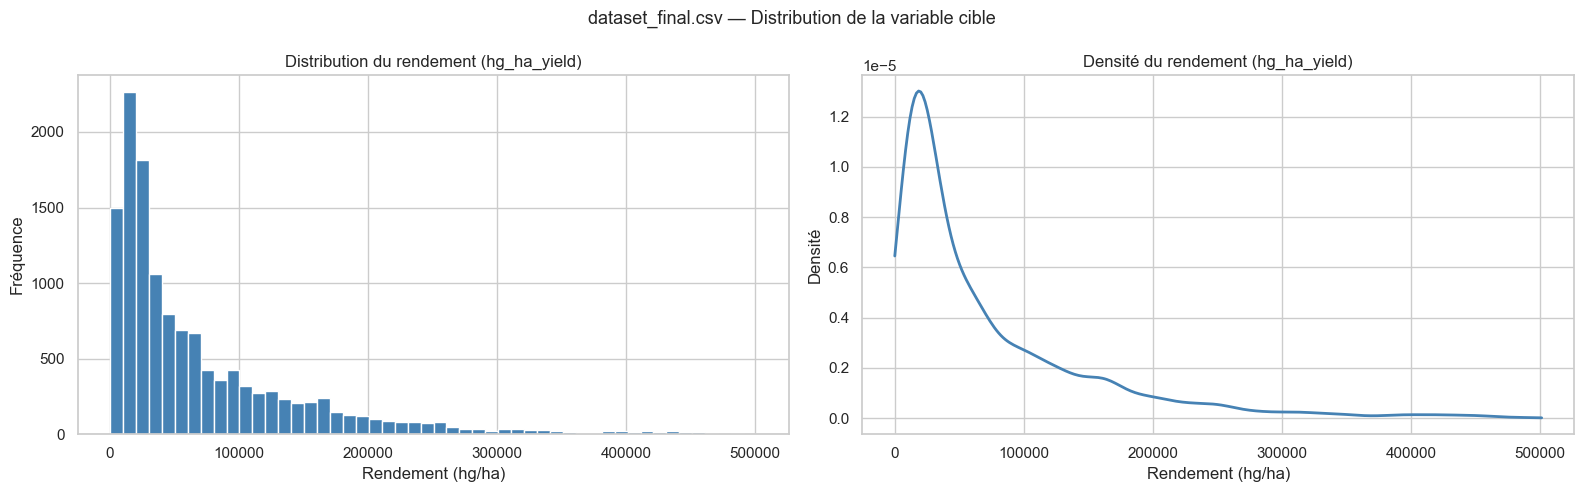

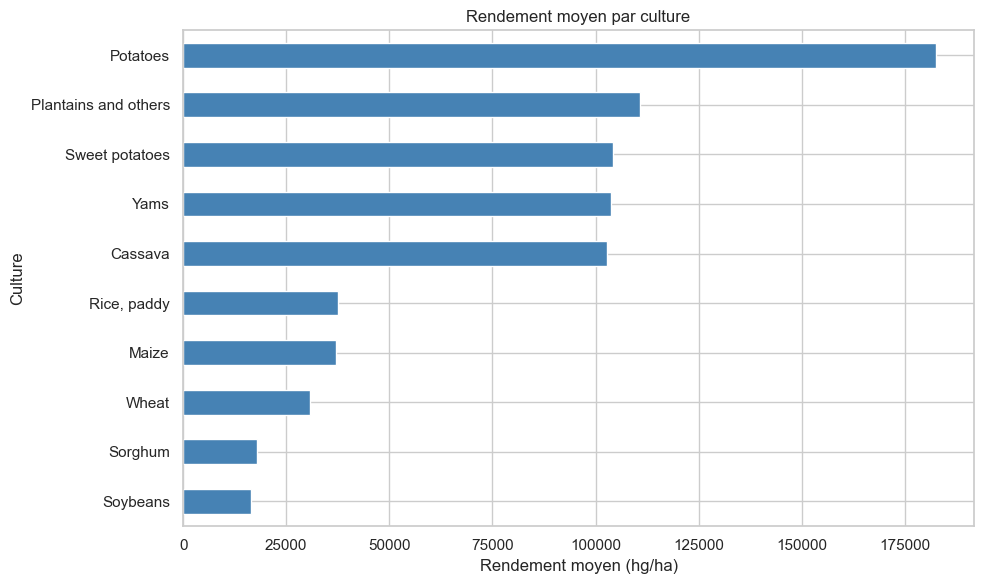

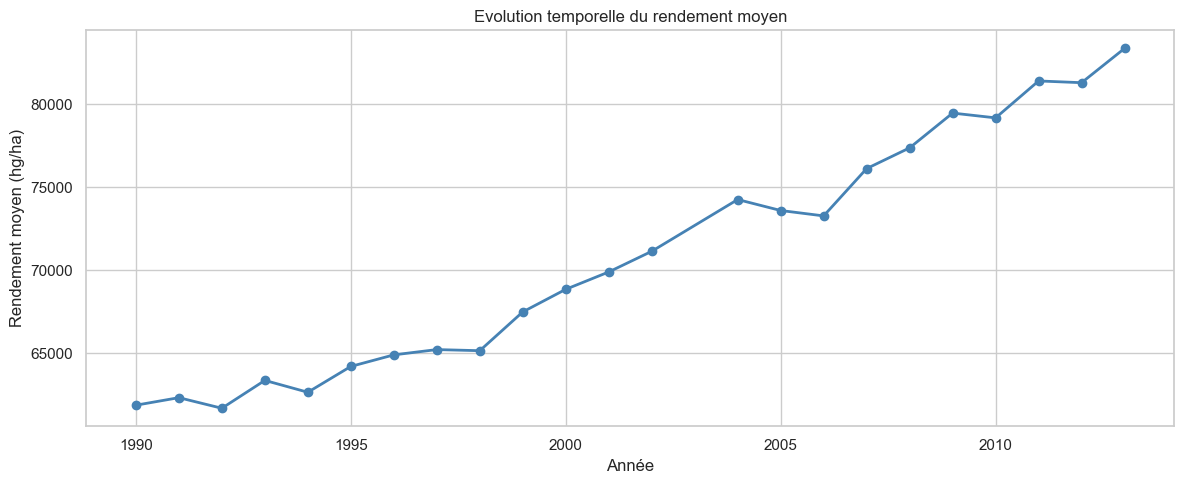

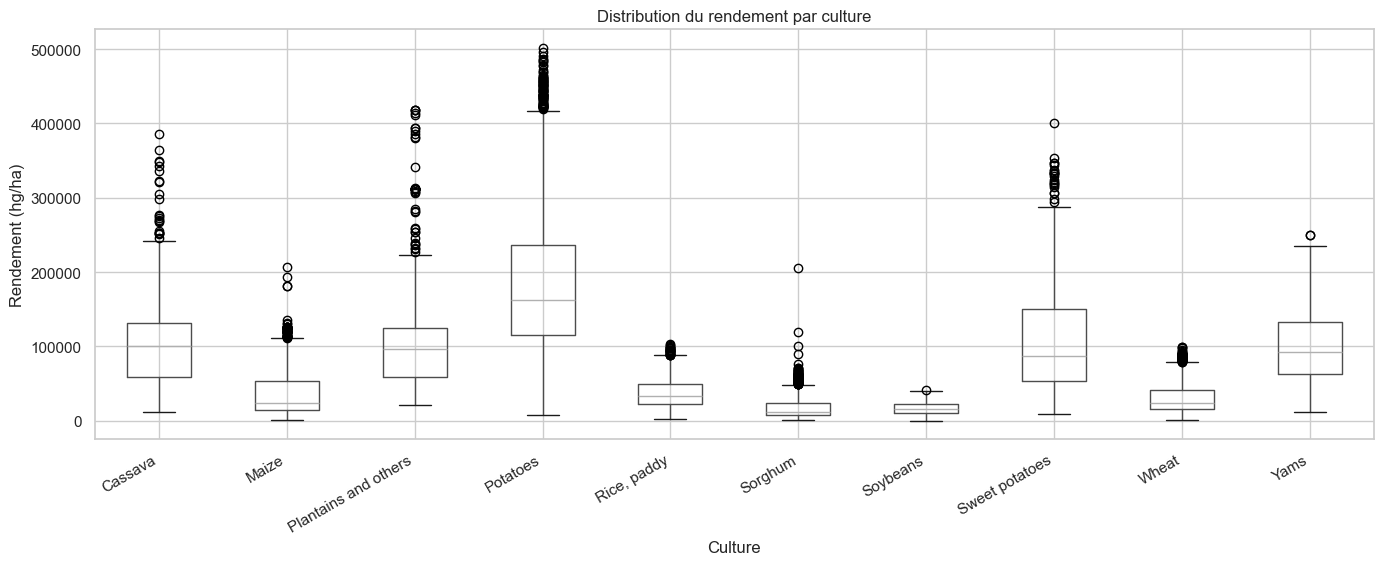

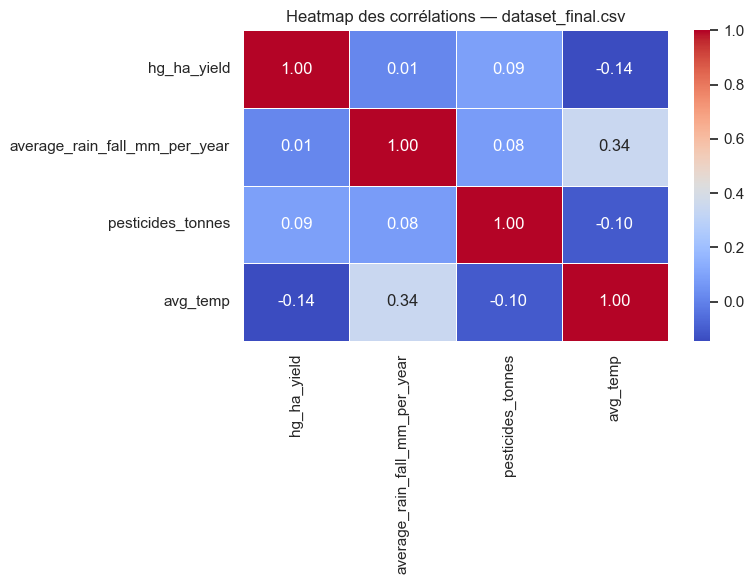

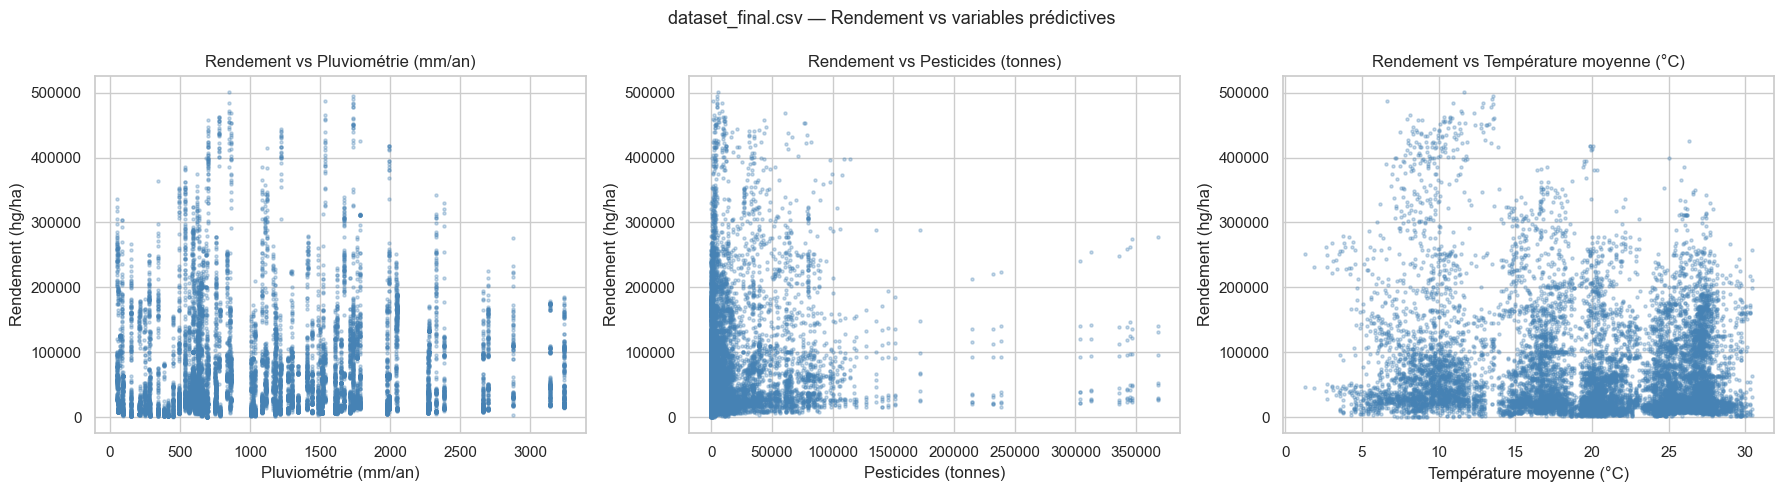

In [17]:
# VISUALISATIONS EXPLORATOIRES
# dataset_final.csv
#_____________________________________________________________

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution de hg_ha_yield
axes[0].hist(yield_df_clean['hg_ha_yield'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du rendement (hg_ha_yield)')
axes[0].set_xlabel('Rendement (hg/ha)')
axes[0].set_ylabel('Fréquence')

# KDE
from scipy.stats import gaussian_kde
import numpy as np
data = yield_df_clean['hg_ha_yield'].dropna()
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 300)
axes[1].plot(x, kde(x), color='steelblue', linewidth=2)
axes[1].set_title('Densité du rendement (hg_ha_yield)')
axes[1].set_xlabel('Rendement (hg/ha)')
axes[1].set_ylabel('Densité')

plt.suptitle('dataset_final.csv — Distribution de la variable cible', fontsize=13)
plt.tight_layout()
plt.show()

# Rendement moyen par culture
fig, ax = plt.subplots(figsize=(10, 6))
rendement_par_culture = yield_df_clean.groupby('Item')['hg_ha_yield'].mean().sort_values()
rendement_par_culture.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Rendement moyen par culture')
ax.set_xlabel('Rendement moyen (hg/ha)')
ax.set_ylabel('Culture')
plt.tight_layout()
plt.show()

# Evolution temporelle du rendement moyen par année
fig, ax = plt.subplots(figsize=(12, 5))
rendement_par_annee = yield_df_clean.groupby('Year')['hg_ha_yield'].mean()
ax.plot(rendement_par_annee.index, rendement_par_annee.values, marker='o', color='steelblue', linewidth=2)
ax.set_title('Evolution temporelle du rendement moyen')
ax.set_xlabel('Année')
ax.set_ylabel('Rendement moyen (hg/ha)')
plt.tight_layout()
plt.show()

# Boxplot du rendement par culture
fig, ax = plt.subplots(figsize=(14, 6))
ordre = yield_df_clean.groupby('Item')['hg_ha_yield'].median().sort_values().index
yield_df_clean.boxplot(column='hg_ha_yield', by='Item', ax=ax,
                       positions=range(len(ordre)),
                       labels=ordre)
ax.set_title('Distribution du rendement par culture')
ax.set_xlabel('Culture')
ax.set_ylabel('Rendement (hg/ha)')
plt.suptitle('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Heatmap des corrélations
fig, ax = plt.subplots(figsize=(8, 6))
colonnes_num = ['hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
corr = yield_df_clean[colonnes_num].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Heatmap des corrélations — dataset_final.csv')
plt.tight_layout()
plt.show()

# Scatter plots rendement vs variables numériques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variables = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
labels    = ['Pluviométrie (mm/an)', 'Pesticides (tonnes)', 'Température moyenne (°C)']

for i, (var, label) in enumerate(zip(variables, labels)):
    axes[i].scatter(yield_df_clean[var], yield_df_clean['hg_ha_yield'],
                    alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Rendement (hg/ha)')
    axes[i].set_title(f'Rendement vs {label}')

plt.suptitle('dataset_final.csv — Rendement vs variables prédictives', fontsize=13)
plt.tight_layout()
plt.show()

### <u>Conclusion:</u>
- **Distribution** : fortement asymétrique à droite, majorité des rendements sous 100 000 hg/ha avec une longue queue.
- **Rendement par culture** : **Potatoes** largement en tête (~180 000 hg/ha), suivi de Plantains, Sweet potatoes et Yams. **Sorghum** et **Soybeans** sont les cultures les moins productives.
- **Evolution temporelle** : tendance haussière claire de 1990 à 2013 (eflet des progrès agronomiques mondiaux sur la période?).
- **Boxplot** : forte variabilité sur Potatoes et Sweet potatoes, cultures très sensibles aux conditions locales.
- **Heatmap** : corrélations linéaires très faibles avec hg_ha_yield (max -0.14 pour avg_temp). Cela suggère des relations non linéaires; ce qui justifie l'utilisation de modèles comme **Random Forest** plutôt qu'une régression linéaire.
- **Scatter plots** : confirment l'absence de relation linéaire directe entre les variables et le rendement.

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">crop_yield_clean.csv </h2>

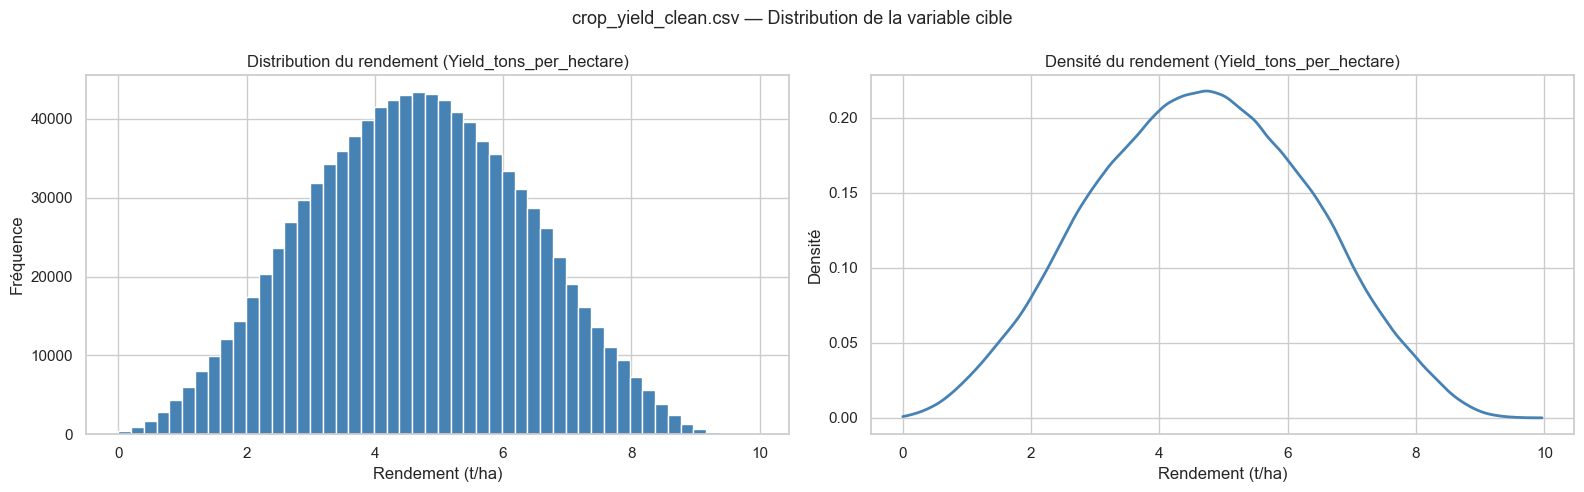

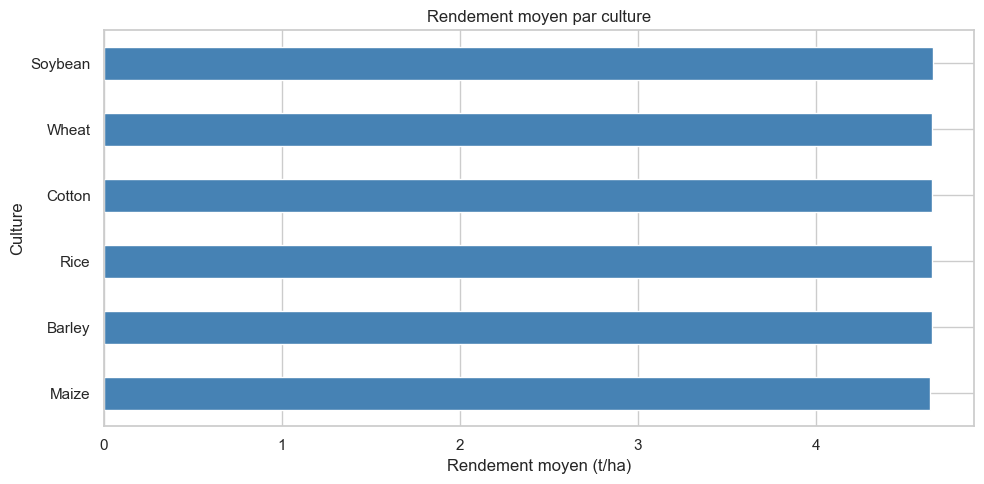

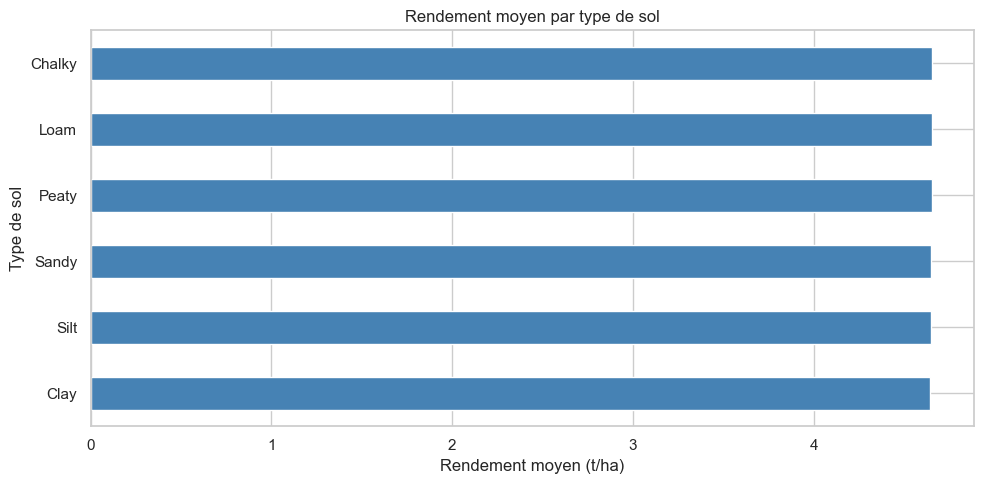

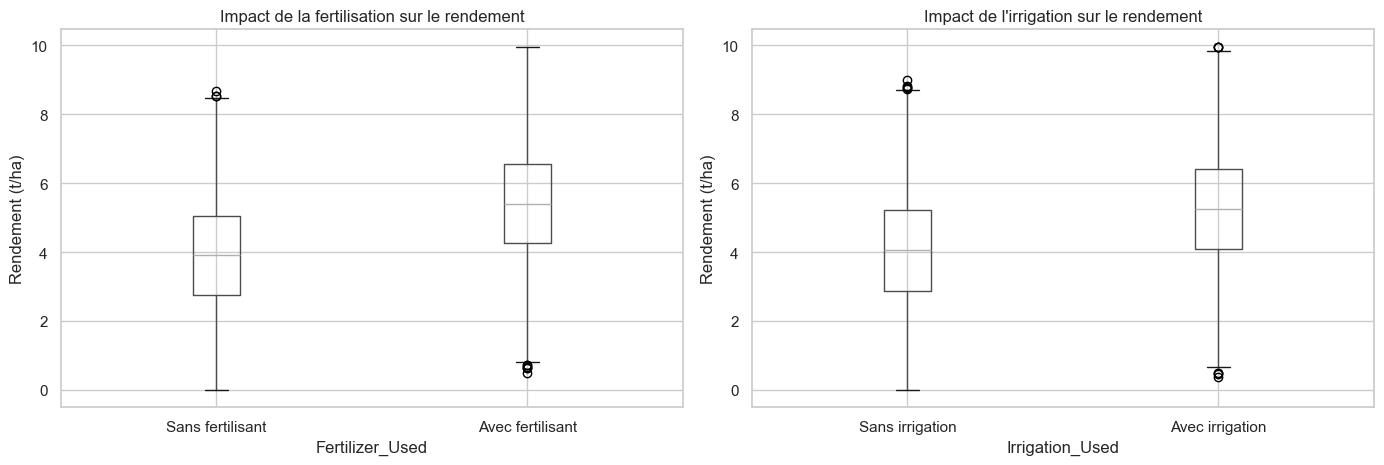

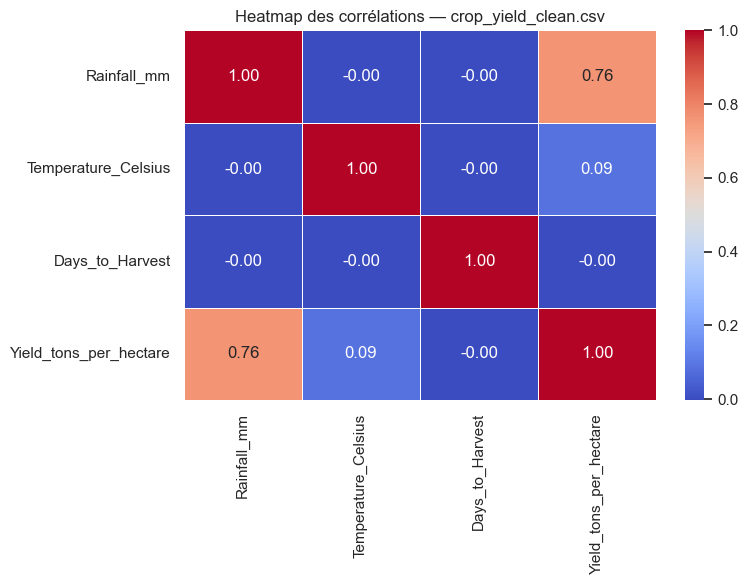

In [18]:
# VISUALISATIONS EXPLORATOIRES
# crop_yield_clean.csv
#_____________________________________________________________

# Distribution de Yield_tons_per_hectare
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(crop_yield_clean['Yield_tons_per_hectare'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du rendement (Yield_tons_per_hectare)')
axes[0].set_xlabel('Rendement (t/ha)')
axes[0].set_ylabel('Fréquence')

data_cy = crop_yield_clean['Yield_tons_per_hectare'].dropna()
kde_cy  = gaussian_kde(data_cy)
x_cy    = np.linspace(data_cy.min(), data_cy.max(), 300)
axes[1].plot(x_cy, kde_cy(x_cy), color='steelblue', linewidth=2)
axes[1].set_title('Densité du rendement (Yield_tons_per_hectare)')
axes[1].set_xlabel('Rendement (t/ha)')
axes[1].set_ylabel('Densité')

plt.suptitle('crop_yield_clean.csv — Distribution de la variable cible', fontsize=13)
plt.tight_layout()
plt.show()

# Rendement moyen par culture
fig, ax = plt.subplots(figsize=(10, 5))
rendement_crop = crop_yield_clean.groupby('Crop')['Yield_tons_per_hectare'].mean().sort_values()
rendement_crop.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Rendement moyen par culture')
ax.set_xlabel('Rendement moyen (t/ha)')
ax.set_ylabel('Culture')
plt.tight_layout()
plt.show()

# Rendement moyen par type de sol
fig, ax = plt.subplots(figsize=(10, 5))
rendement_sol = crop_yield_clean.groupby('Soil_Type')['Yield_tons_per_hectare'].mean().sort_values()
rendement_sol.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Rendement moyen par type de sol')
ax.set_xlabel('Rendement moyen (t/ha)')
ax.set_ylabel('Type de sol')
plt.tight_layout()
plt.show()

# Impact de Fertilizer_Used et Irrigation_Used sur le rendement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crop_yield_clean.boxplot(column='Yield_tons_per_hectare', by='Fertilizer_Used',
                         ax=axes[0])
axes[0].set_title('Impact de la fertilisation sur le rendement')
axes[0].set_xlabel('Fertilizer_Used')
axes[0].set_ylabel('Rendement (t/ha)')
plt.sca(axes[0])
plt.xticks([1, 2], ['Sans fertilisant', 'Avec fertilisant'])

crop_yield_clean.boxplot(column='Yield_tons_per_hectare', by='Irrigation_Used',
                         ax=axes[1])
axes[1].set_title("Impact de l'irrigation sur le rendement")
axes[1].set_xlabel('Irrigation_Used')
axes[1].set_ylabel('Rendement (t/ha)')
plt.sca(axes[1])
plt.xticks([1, 2], ['Sans irrigation', 'Avec irrigation'])

plt.suptitle('')
plt.tight_layout()
plt.show()

# Heatmap des corrélations (variables numériques uniquement)
fig, ax = plt.subplots(figsize=(8, 6))
colonnes_num_cy = ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest',
                   'Yield_tons_per_hectare']
corr_cy = crop_yield_clean[colonnes_num_cy].corr()
sns.heatmap(corr_cy, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5)
ax.set_title('Heatmap des corrélations — crop_yield_clean.csv')
plt.tight_layout()
plt.show()

### <u>Conclusion:</u>
- **Distribution** : parfaitement symétrique et proche d'une distribution normale centrée autour de 4.5 t/ha. <mark>dataset synthétique</mark>
- **Rendement par culture** : toutes les cultures ont exactement le même rendement moyen (~4.7 t/ha). Confirmation que le dataset est synthétique : dans la réalité, les cultures ont des rendements très différents comme on le voit dans dataset_final.csv.
- **Rendement par type de sol** : même constat, aucune différence entre les types de sol. Les variables catégorielles n'influencent pas le rendement de façon différenciée.
- **Fertilisation et irrigation** : c'est le seul signal intéressant, avec fertilisant ou irrigation, la médiane et le Q3 sont légèrement plus élevés et la distribution est plus resserrée vers le haut.
- **Heatmap** : <mark>Rainfall_mm est fortement corrélée à Yield_tons_per_hectare (0.76)</mark>. C'est la seule variable numérique vraiment prédictive dans ce dataset.


<h1 style="color: #1e3a8a; background-color: #dbeafe; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Analyse en composantes principales</h1>

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">dataset_final.csv</h2>

Variance expliquée par composante :
  PC1 : 34.38%  (cumulée : 34.38%)
  PC2 : 28.17%  (cumulée : 62.55%)
  PC3 : 22.54%  (cumulée : 85.09%)
  PC4 : 14.91%  (cumulée : 100.00%)


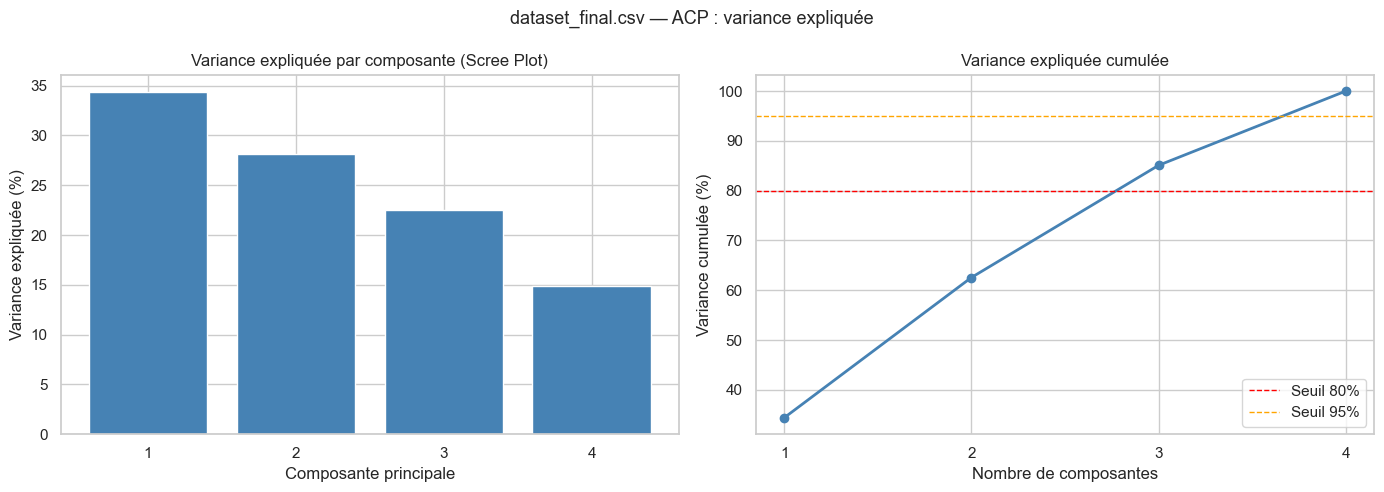


Loadings (contribution des variables aux composantes) :


,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
PC1,-0.288,0.618,-0.144,0.717
PC2,0.567,0.442,0.694,-0.015
PC3,0.743,0.082,-0.657,0.096
PC4,0.208,-0.644,0.255,0.690


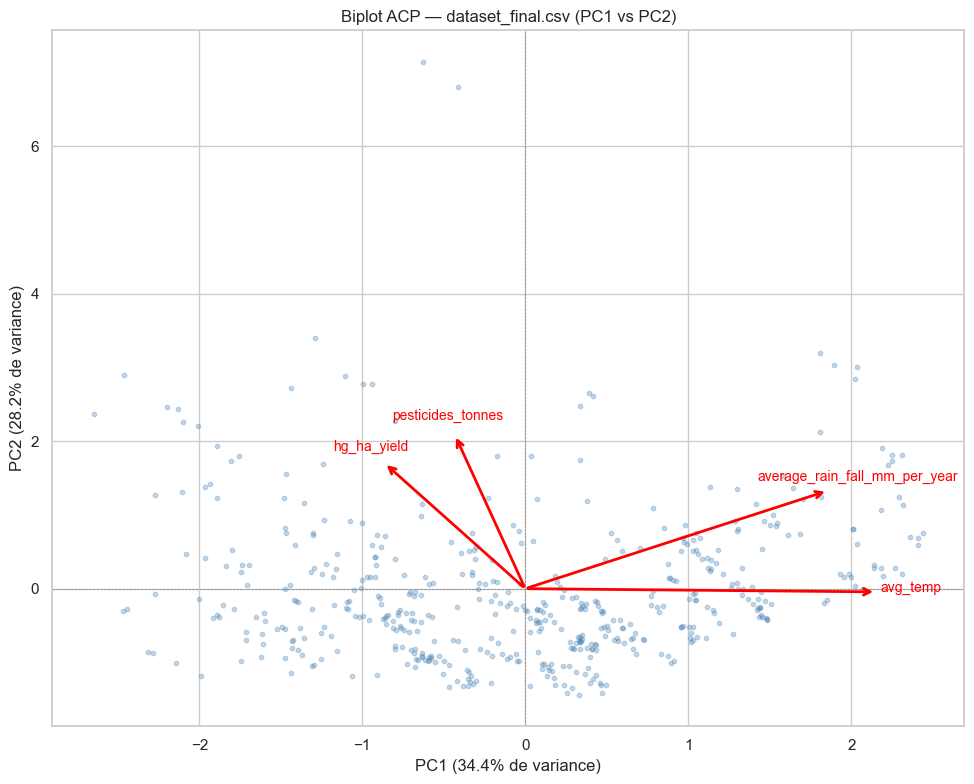

In [19]:
# ACP - dataset_final.csv
#_____________________________________________________________

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Variables numériques retenues pour l'ACP
colonnes_acp = ['hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(yield_df_clean[colonnes_acp])

# Application de la PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
variance_expliquee = pca.explained_variance_ratio_
variance_cumulee   = np.cumsum(variance_expliquee)

print("Variance expliquée par composante :")
for i, (var, cum) in enumerate(zip(variance_expliquee, variance_cumulee)):
    print(f"  PC{i+1} : {var*100:.2f}%  (cumulée : {cum*100:.2f}%)")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(variance_expliquee)+1), variance_expliquee * 100, color='steelblue')
axes[0].set_title('Variance expliquée par composante (Scree Plot)')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_xticks(range(1, len(variance_expliquee)+1))

axes[1].plot(range(1, len(variance_cumulee)+1), variance_cumulee * 100,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1, label='Seuil 80%')
axes[1].axhline(y=95, color='orange', linestyle='--', linewidth=1, label='Seuil 95%')
axes[1].set_title('Variance expliquée cumulée')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_xticks(range(1, len(variance_cumulee)+1))
axes[1].legend()

plt.suptitle('dataset_final.csv — ACP : variance expliquée', fontsize=13)
plt.tight_layout()
plt.show()

# Loadings (contributions des variables aux composantes)
loadings = pca.components_
print("\nLoadings (contribution des variables aux composantes) :")
loadings_df = pd.DataFrame(
    loadings,
    columns=colonnes_acp,
    index=[f'PC{i+1}' for i in range(len(loadings))]
)
display(loadings_df.round(3))

# Biplot PC1 / PC2
fig, ax = plt.subplots(figsize=(10, 8))

# Projection des individus (échantillon de 500 pour la lisibilité)
sample_idx = np.random.choice(len(X_pca), size=500, replace=False)
ax.scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
           alpha=0.3, s=10, color='steelblue', label='Observations')

# Projection des variables
scale = 3
for i, var in enumerate(colonnes_acp):
    ax.annotate('', xy=(loadings[0, i] * scale, loadings[1, i] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(loadings[0, i] * scale * 1.1, loadings[1, i] * scale * 1.1,
            var, color='red', fontsize=10, ha='center')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({variance_expliquee[0]*100:.1f}% de variance)')
ax.set_ylabel(f'PC2 ({variance_expliquee[1]*100:.1f}% de variance)')
ax.set_title('Biplot ACP — dataset_final.csv (PC1 vs PC2)')
plt.tight_layout()
plt.show()

### Interprétation des résultats :

#### <u>Variance expliquée</u>

La variance est distribuée de façon relativement uniforme entre les 4 composantes :
PC1 (34.38%), PC2 (28.17%), PC3 (22.54%), PC4 (14.91%).
Aucune composante ne domine clairement, ce qui reflète la faible corrélation entre les variables déjà observée sur la heatmap. Il faut 3 composantes pour dépasser le seuil de 80% (85.09%).

#### <u>Interprétation des composantes</u>

**<mark>PC1 (34.38%) - axe climatique</mark>**
Dominée par `avg_temp` (0.717) et `average_rain_fall_mm_per_year` (0.618).
Cet axe oppose les pays chauds et pluvieux aux pays froids et secs.
La variable cible `hg_ha_yield` y contribue peu (-0.288) : le climat seul
n'explique pas directement le rendement.

**<mark>PC2 (28.17%) — axe rendement / intrants</mark>**
Dominée par `pesticides_tonnes` (0.694) et `hg_ha_yield` (0.567).
Les pays qui utilisent davantage de pesticides tendent à afficher des rendements plus élevés.

**<mark>PC3 (22.54%) — axe rendement pur</mark>**
`hg_ha_yield` domine fortement (0.743) en opposition à `pesticides_tonnes` (-0.657).
Cet axe distingue les pays à haut rendement avec peu d'intrants chimiques, potentiellement liés à des cultures naturellement productives comme Potatoes et Sweet potatoes.

#### <u>Lecture du biplot</u>

- `avg_temp` et `average_rain_fall_mm_per_year` pointent vers la droite sur PC1 :
  ce sont des variables climatiques indépendantes du rendement.
- `hg_ha_yield` et `pesticides_tonnes` pointent vers le haut sur PC2 :
  ils sont associés positivement dans un axe rendement / intensification agricole.
- La dispersion importante des individus sans structure de clusters confirme
  l'absence de groupes distincts dans les données — cohérent avec la heatmap.

#### <u>Conclusion</u>

- **Aucune variable** ne domine suffisamment pour être écartée.
- `avg_temp`, `average_rain_fall_mm_per_year` et `pesticides_tonnes` apportent
chacune une information distincte et complémentaire sur des dimensions différentes
(climatique, technologique, rendement pur).

Toutes les variables numériques seront conservées comme features dans le modèle ML.
La faiblesse des corrélations linéaires et la structure dispersée du biplot confirment
la pertinence de modèles capturant des relations non linéaires,
tels que le **Random Forest** ou le **Gradient Boosting**.

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">crop_yield_clean.csv </h2>

Region : {'East': np.int64(0), 'North': np.int64(1), 'South': np.int64(2), 'West': np.int64(3)}
Soil_Type : {'Chalky': np.int64(0), 'Clay': np.int64(1), 'Loam': np.int64(2), 'Peaty': np.int64(3), 'Sandy': np.int64(4), 'Silt': np.int64(5)}
Crop : {'Barley': np.int64(0), 'Cotton': np.int64(1), 'Maize': np.int64(2), 'Rice': np.int64(3), 'Soybean': np.int64(4), 'Wheat': np.int64(5)}
Weather_Condition : {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Sunny': np.int64(2)}

Variance expliquée par composante :
  PC1 : 19.54%  (cumulée : 19.54%)
  PC2 : 10.04%  (cumulée : 29.58%)
  PC3 : 10.04%  (cumulée : 39.62%)
  PC4 : 10.01%  (cumulée : 49.63%)
  PC5 : 10.01%  (cumulée : 59.64%)
  PC6 : 9.99%  (cumulée : 69.64%)
  PC7 : 9.98%  (cumulée : 79.62%)
  PC8 : 9.97%  (cumulée : 89.59%)
  PC9 : 9.96%  (cumulée : 99.56%)
  PC10 : 0.44%  (cumulée : 100.00%)


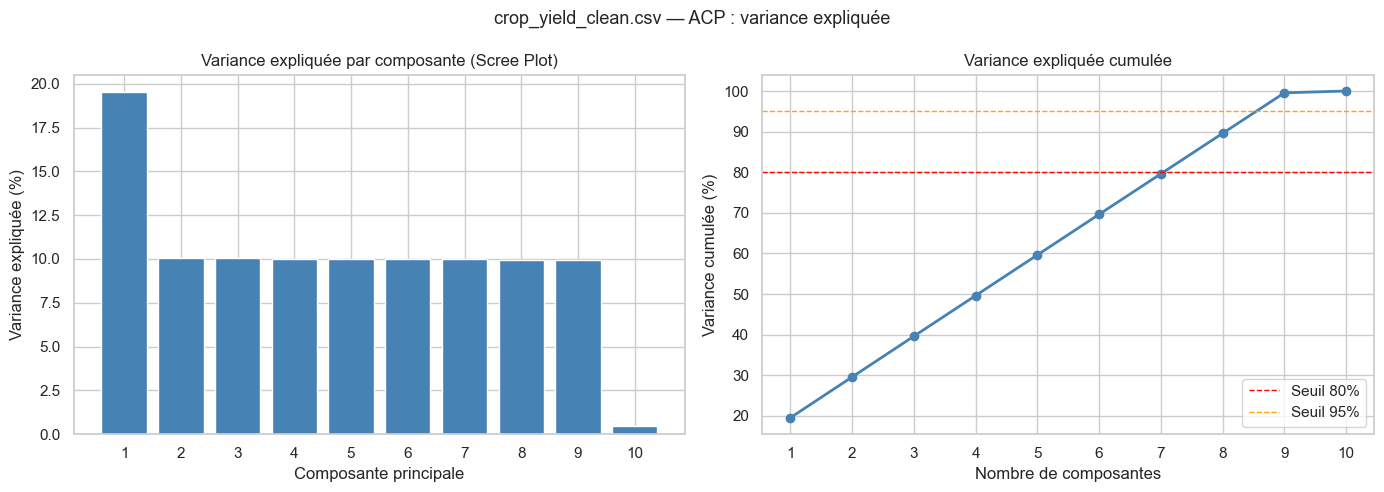


Loadings (contribution des variables aux composantes) :


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare,Region_enc,Soil_Type_enc,Crop_enc,Weather_Condition_enc,Fertilizer_Used_enc,Irrigation_Used_enc
PC1,0.566,0.064,-0.004,0.707,0.001,-0.000,0.002,0.002,0.327,0.262
PC2,-0.456,0.448,0.029,-0.001,0.232,0.154,0.269,-0.346,0.517,0.231
PC3,-0.136,0.077,0.208,0.001,-0.452,0.577,-0.150,0.520,0.303,-0.101
PC4,-0.125,-0.473,0.538,0.002,-0.353,-0.043,0.261,-0.235,-0.061,0.466
PC5,0.322,0.163,0.284,0.000,-0.008,0.286,0.605,-0.203,-0.173,-0.519
PC6,0.036,0.351,0.607,0.003,-0.101,-0.369,-0.493,-0.205,0.084,-0.261
PC7,-0.015,-0.383,0.403,0.001,0.750,0.130,-0.065,0.265,0.171,-0.086
PC8,0.106,0.213,0.083,0.001,0.183,0.579,-0.363,-0.271,-0.496,0.343
PC9,-0.021,0.468,0.221,-0.001,0.106,-0.266,0.302,0.573,-0.333,0.346
PC10,-0.566,-0.063,-0.000,0.707,0.000,0.000,0.000,-0.000,-0.327,-0.262


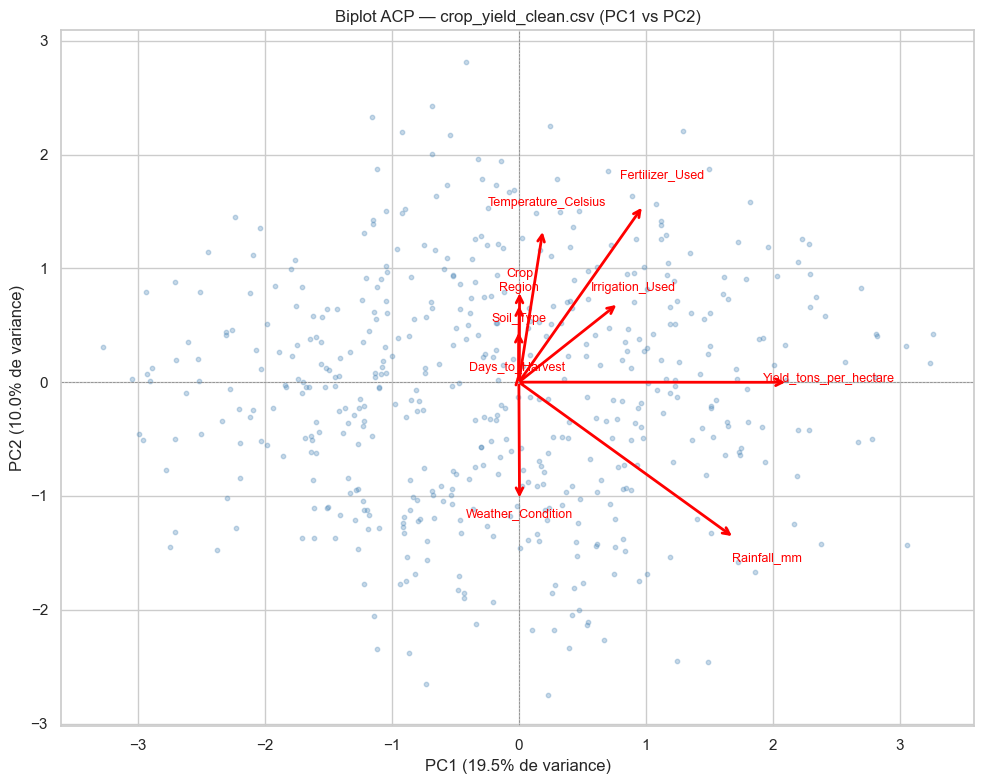

In [20]:
# ACP - crop_yield_clean.csv
#_____________________________________________________________

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import numpy as np

# Encodage des variables catégorielles et booléennes
crop_yield_acp = crop_yield_clean.copy()

colonnes_cat = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
for col in colonnes_cat:
    le = LabelEncoder()
    crop_yield_acp[col + '_enc'] = le.fit_transform(crop_yield_acp[col])
    print(f"{col} : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Conversion des booléens en entiers
crop_yield_acp['Fertilizer_Used_enc'] = crop_yield_acp['Fertilizer_Used'].astype(int)
crop_yield_acp['Irrigation_Used_enc'] = crop_yield_acp['Irrigation_Used'].astype(int)

# Variables retenues pour l'ACP
colonnes_acp_cy = [
    'Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest',
    'Yield_tons_per_hectare', 'Region_enc', 'Soil_Type_enc',
    'Crop_enc', 'Weather_Condition_enc',
    'Fertilizer_Used_enc', 'Irrigation_Used_enc'
]

# Standardisation
scaler_cy = StandardScaler()
X_scaled_cy = scaler_cy.fit_transform(crop_yield_acp[colonnes_acp_cy])

# Application de la PCA
pca_cy = PCA()
X_pca_cy = pca_cy.fit_transform(X_scaled_cy)

# Variance expliquée
variance_expliquee_cy = pca_cy.explained_variance_ratio_
variance_cumulee_cy   = np.cumsum(variance_expliquee_cy)

print("\nVariance expliquée par composante :")
for i, (var, cum) in enumerate(zip(variance_expliquee_cy, variance_cumulee_cy)):
    print(f"  PC{i+1} : {var*100:.2f}%  (cumulée : {cum*100:.2f}%)")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(variance_expliquee_cy)+1),
            variance_expliquee_cy * 100, color='steelblue')
axes[0].set_title('Variance expliquée par composante (Scree Plot)')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_xticks(range(1, len(variance_expliquee_cy)+1))

axes[1].plot(range(1, len(variance_cumulee_cy)+1), variance_cumulee_cy * 100,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1, label='Seuil 80%')
axes[1].axhline(y=95, color='orange', linestyle='--', linewidth=1, label='Seuil 95%')
axes[1].set_title('Variance expliquée cumulée')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_xticks(range(1, len(variance_cumulee_cy)+1))
axes[1].legend()

plt.suptitle('crop_yield_clean.csv — ACP : variance expliquée', fontsize=13)
plt.tight_layout()
plt.show()

# Loadings
loadings_cy = pca_cy.components_
loadings_cy_df = pd.DataFrame(
    loadings_cy,
    columns=colonnes_acp_cy,
    index=[f'PC{i+1}' for i in range(len(loadings_cy))]
)
print("\nLoadings (contribution des variables aux composantes) :")
display(loadings_cy_df.round(3))

# Biplot PC1 / PC2
fig, ax = plt.subplots(figsize=(10, 8))

sample_idx = np.random.choice(len(X_pca_cy), size=500, replace=False)
ax.scatter(X_pca_cy[sample_idx, 0], X_pca_cy[sample_idx, 1],
           alpha=0.3, s=10, color='steelblue')

scale = 3
for i, var in enumerate(colonnes_acp_cy):
    ax.annotate('', xy=(loadings_cy[0, i] * scale, loadings_cy[1, i] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(loadings_cy[0, i] * scale * 1.15, loadings_cy[1, i] * scale * 1.15,
            var.replace('_enc', ''), color='red', fontsize=9, ha='center')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({variance_expliquee_cy[0]*100:.1f}% de variance)')
ax.set_ylabel(f'PC2 ({variance_expliquee_cy[1]*100:.1f}% de variance)')
ax.set_title('Biplot ACP — crop_yield_clean.csv (PC1 vs PC2)')
plt.tight_layout()
plt.show()

### Interprétation des résultats

#### <u>Variance expliquée</u>

**PC1** capture 19.54% de la variance, puis toutes les composantes suivantes
capturent environ 10%.
Cette distribution uniforme est la signature d'un dataset synthétique
dont les variables ont été générées de façon indépendante les unes des autres.
Il faut 7 composantes pour dépasser le seuil de 80% et 9 pour atteindre 95%.
La réduction de dimensionnalité est quasi impossible, il n'existe pas de structure
latente à exploiter.

#### <u>Interprétation des composantes</u>

**<mark>PC1 (19.54%) - axe pluviométrie / rendement</mark>**
Dominée par `Yield_tons_per_hectare` (0.707) et `Rainfall_mm` (0.566).
Confirme la corrélation forte (0.76) observée sur la heatmap.
C'est la seule relation structurelle qui semble réelle dans ce dataset.

**<mark>PC2 (10.04%) - axe intrants / température</mark>**
Dominée par `Fertilizer_Used` (0.517) et `Temperature_Celsius` (0.448).
Le signal est faible et difficile à interpréter.

**<mark>PC3 à PC9 - axes indépendants</mark>**
Chaque composante est capturée par une variable différente de façon quasi exclusive.
C'est la preuve que les variables ont été générées sans corrélation entre elles (comportement typique d'un dataset synthétique).

#### <u>Lecture du biplot</u>

- `Rainfall_mm` et `Yield_tons_per_hectare` pointent dans la même direction sur PC1,
confirmant leur relation directe et leur rôle central dans le dataset.
- `Fertilizer_Used` et `Irrigation_Used` pointent dans la même direction (haut-droite)
avec des flèches longues, elles sont corrélées entre elles et exercent un effet
positif commun sur le rendement (cohérent avec les boxplots observés précédemment).
- `Temperature_Celsius` présente une contribution modérée mais réelle, dans une direction
distincte des autres variables.
- En revanche, `Crop`, `Region`, `Soil_Type`, `Days_to_Harvest` et `Weather_Condition`
affichent des flèches courtes sans direction significative, ces variables catégorielles
n'ont pas été générées avec un effet différencié sur le rendement.

#### <u>Limites de cette ACP</u>

Le dataset présente un signal agronomique partiel : `Rainfall_mm`, `Fertilizer_Used`
et `Irrigation_Used` contribuent de façon cohérente au rendement.
En revanche, l'absence de différenciation entre les cultures, les types de sol et
les régions confirme que ces variables n'ont aucun pouvoir explicatif sur le rendement
dans ce dataset. Cette limite est inhérente à sa nature synthétique et non à une
erreur d'analyse.

#### <u>Conclusion</u>

- Cette ACP répond à la demande explicite de Gabriel concernant l'Agriculture CropYield
Dataset.
- Elle identifie trois variables agronomiques avec un signal réel :
`Rainfall_mm`, `Fertilizer_Used` et `Irrigation_Used`.

Ces résultats ne remettent pas en cause la stratégie retenue : `dataset_final.csv`
reste la source de vérité pour la modélisation, car ses données FAO réelles
présentent des patterns agronomiques cohérents, différenciés et interprétables
sur l'ensemble des cultures et des pays.